# 🏦 Credit Risk Modeling: Loan Default Prediction

**Objective:** Predict the likelihood of a loan default and optimize the decision threshold based on cost-benefit analysis.

**Skills Covered:**
- Binary classification modeling (Logistic Regression, CatBoost)
- Cost-based evaluation metrics
- Risk modeling and scoring
- Feature importance analysis

**Target Variable:** `loan_status` — 0 = No Default, 1 = Default

## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)
from catboost import CatBoostClassifier

# Plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 📂 Step 2: Load & Explore the Dataset

The dataset contains 32,581 loan applications with 12 features including borrower demographics, loan details, and credit history.

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')

print(f'Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\n--- First 5 Rows ---')
df.head()

Dataset Shape: 32,581 rows × 12 columns

--- First 5 Rows ---


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
print('--- Data Types & Missing Values ---')
info = pd.DataFrame({
    'dtype': df.dtypes,
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info.to_string())

--- Data Types & Missing Values ---
                              dtype  missing  missing_%
person_age                    int64        0       0.00
person_income                 int64        0       0.00
person_home_ownership           str        0       0.00
person_emp_length           float64      895       2.75
loan_intent                     str        0       0.00
loan_grade                      str        0       0.00
loan_amnt                     int64        0       0.00
loan_int_rate               float64     3116       9.56
loan_status                   int64        0       0.00
loan_percent_income         float64        0       0.00
cb_person_default_on_file       str        0       0.00
cb_person_cred_hist_length    int64        0       0.00


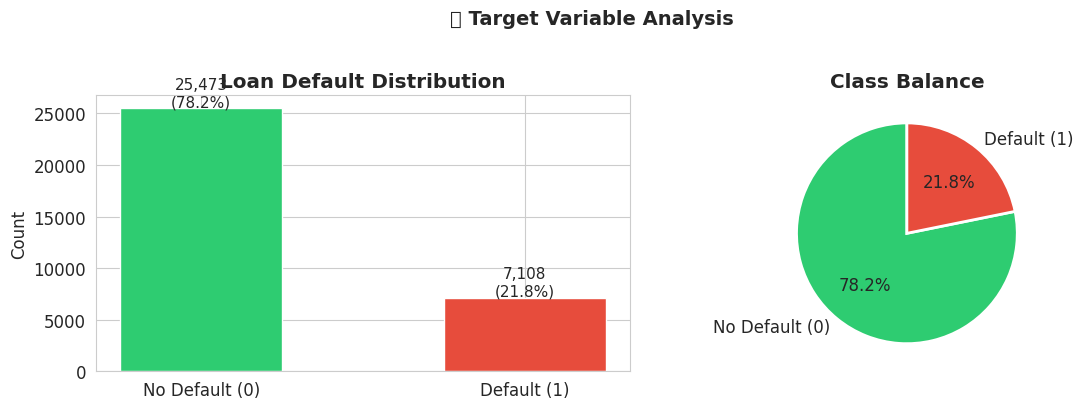


💡 Insight: Dataset is imbalanced — 21.8% defaults.
   This means a naive model predicting "no default" would get ~78% accuracy.
   We must optimize for BUSINESS COST, not just accuracy.


In [4]:
# Target variable distribution
counts = df['loan_status'].value_counts()
labels = ['No Default (0)', 'Default (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(labels, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Loan Default Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance', fontweight='bold')

plt.suptitle('📊 Target Variable Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n💡 Insight: Dataset is imbalanced — {counts[1]/len(df)*100:.1f}% defaults.')
print('   This means a naive model predicting "no default" would get ~78% accuracy.')
print('   We must optimize for BUSINESS COST, not just accuracy.')

## 🔍 Step 3: Exploratory Data Analysis (EDA)

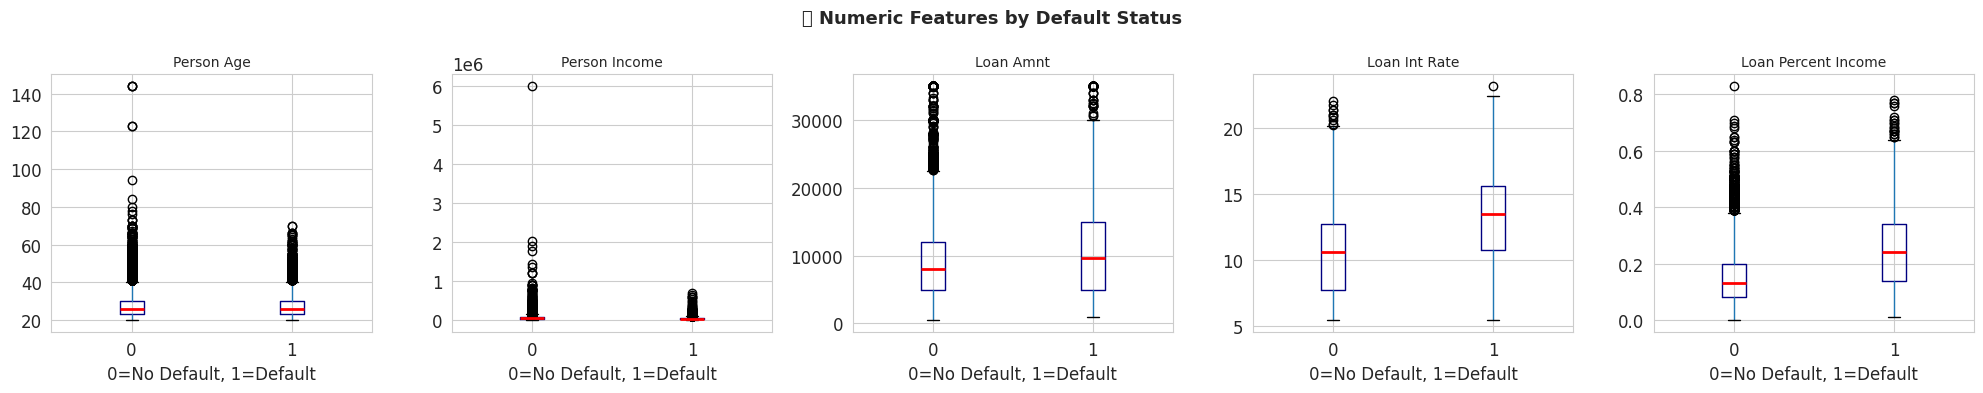

💡 Key Observations:
   • Higher interest rate → higher default risk
   • Higher loan_percent_income → higher default risk (loan burden)
   • Lower income → slightly higher default tendency


In [5]:
# Key numeric features vs default rate
num_cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))

for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by='loan_status', ax=ax,
               boxprops=dict(color='navy'), medianprops=dict(color='red', linewidth=2))
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('0=No Default, 1=Default')
    ax.set_ylabel('')

plt.suptitle('📦 Numeric Features by Default Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Key Observations:')
print('   • Higher interest rate → higher default risk')
print('   • Higher loan_percent_income → higher default risk (loan burden)')
print('   • Lower income → slightly higher default tendency')

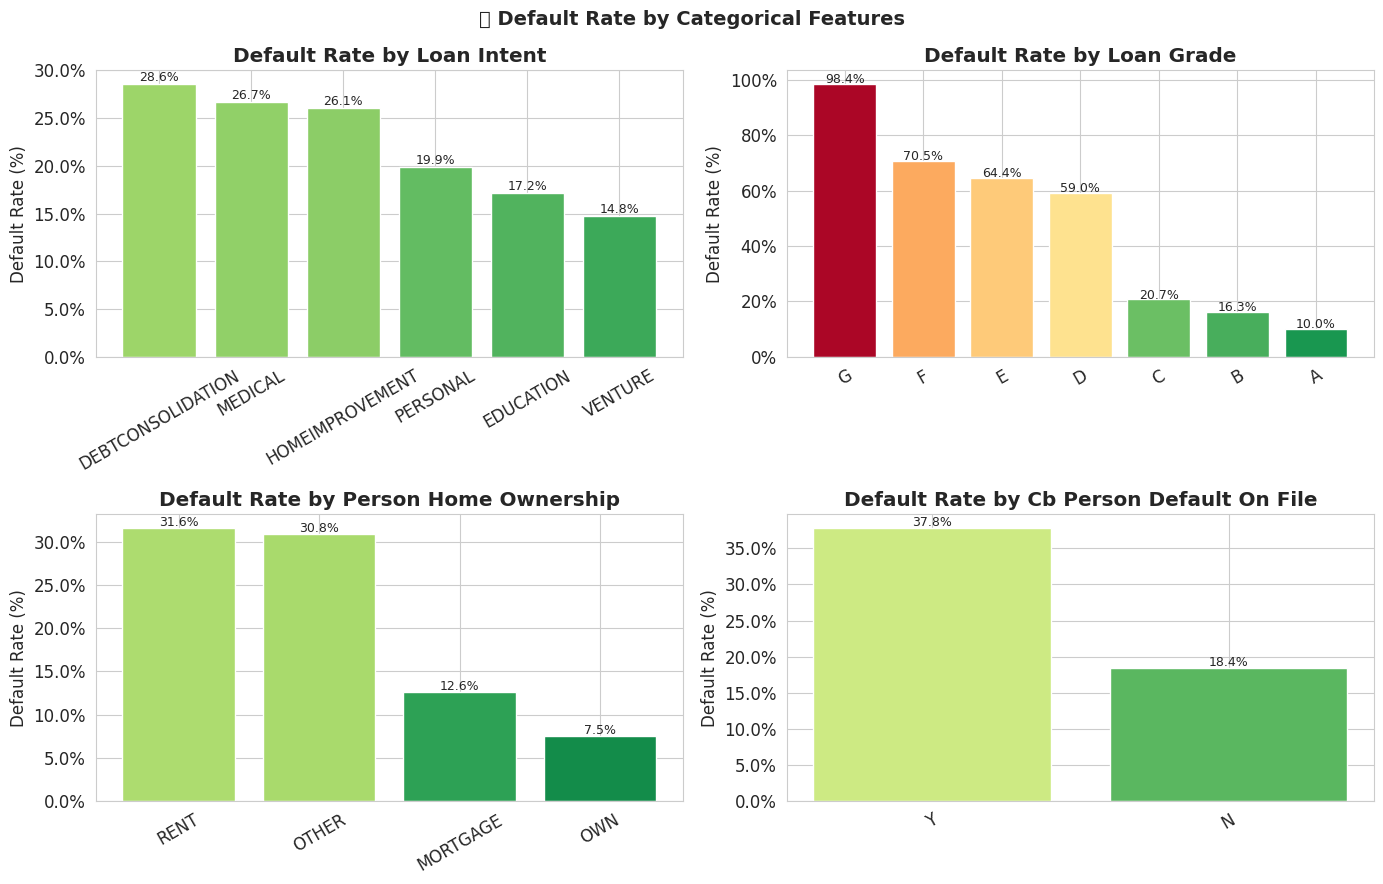

💡 Key Observations:
   • Loan grade G/F has drastically higher default rates
   • Borrowers with prior defaults (cb_person_default_on_file=Y) default more
   • Debt consolidation and medical loans show elevated risk


In [6]:
# Default rate by categorical features
cat_cols = ['loan_intent', 'loan_grade', 'person_home_ownership', 'cb_person_default_on_file']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    default_rate = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
    bars = ax.bar(default_rate.index, default_rate.values * 100,
                  color=plt.cm.RdYlGn_r(default_rate.values), edgecolor='white')
    ax.set_title(f'Default Rate by {col.replace("_", " ").title()}', fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylabel('Default Rate (%)')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, default_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val*100:.1f}%', ha='center', fontsize=9)

plt.suptitle('📊 Default Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Key Observations:')
print('   • Loan grade G/F has drastically higher default rates')
print('   • Borrowers with prior defaults (cb_person_default_on_file=Y) default more')
print('   • Debt consolidation and medical loans show elevated risk')

## 🧹 Step 4: Data Cleaning & Preprocessing

**Actions:**
1. Remove outliers (age >80 is unrealistic for a borrower)
2. Cap extreme income values
3. Impute missing values with median
4. Encode categorical variables
5. Scale numeric features for Logistic Regression

In [7]:
df_clean = df.copy()

# ── 1. Remove unrealistic ages (dataset has a 144-year-old!)
print(f'Rows before age filter: {len(df_clean):,}')
df_clean = df_clean[df_clean['person_age'] <= 80]
print(f'Rows after removing age > 80: {len(df_clean):,}')

# ── 2. Cap extreme employment length (123 years is impossible)
df_clean = df_clean[df_clean['person_emp_length'] <= 60]
print(f'Rows after capping emp_length: {len(df_clean):,}')

# ── 3. Impute missing numeric values with median
df_clean['loan_int_rate'] = df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median())
df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median())
print(f'\nMissing values remaining: {df_clean.isnull().sum().sum()}')

# ── 4. Encode binary categorical: Y/N → 1/0
df_clean['cb_person_default_on_file'] = (df_clean['cb_person_default_on_file'] == 'Y').astype(int)

# ── 5. One-hot encode multi-category columns
df_clean = pd.get_dummies(df_clean,
    columns=['person_home_ownership', 'loan_intent', 'loan_grade'],
    drop_first=True)

print(f'\nFinal cleaned dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print('✅ Preprocessing complete')

Rows before age filter: 32,581
Rows after removing age > 80: 32,574
Rows after capping emp_length: 31,677

Missing values remaining: 0

Final cleaned dataset: 31,677 rows × 23 columns
✅ Preprocessing complete


## ✂️ Step 5: Train-Test Split

In [8]:
X = df_clean.drop('loan_status', axis=1)
y = df_clean['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set:  {X_train.shape[0]:,} samples')
print(f'Test set:      {X_test.shape[0]:,} samples')
print(f'Features:      {X_train.shape[1]}')
print(f'\nClass balance in test set:')
print(y_test.value_counts(normalize=True).mul(100).round(1).to_string())
print('\n💡 Stratify=True ensures the same class ratio in both splits')

Training set:  25,341 samples
Test set:      6,336 samples
Features:      22

Class balance in test set:
loan_status
0    78.5
1    21.5

💡 Stratify=True ensures the same class ratio in both splits


## 🤖 Step 6: Train Models

### Model 1: Logistic Regression (Baseline)
- Simple, interpretable, fast
- Good starting point to understand feature effects
- `class_weight='balanced'` compensates for class imbalance

In [9]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # penalizes missing defaults more
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_probs)

print(f'✅ Logistic Regression trained')
print(f'   ROC-AUC: {lr_auc:.4f}')

✅ Logistic Regression trained
   ROC-AUC: 0.8769


### Model 2: CatBoost
- Gradient boosting — handles non-linear relationships
- More powerful than Logistic Regression for tabular data
- `scale_pos_weight` adjusts for class imbalance

In [10]:
# class imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

cb_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=scale,
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)
cb_model.fit(X_train, y_train)

cb_probs = cb_model.predict_proba(X_test)[:, 1]
cb_auc   = roc_auc_score(y_test, cb_probs)

print(f'✅ CatBoost trained')
print(f'   ROC-AUC: {cb_auc:.4f}')
print(f'\n💡 AUC > 0.5 = better than random. AUC = 1.0 = perfect. Target: > 0.80')

✅ CatBoost trained
   ROC-AUC: 0.9412

💡 AUC > 0.5 = better than random. AUC = 1.0 = perfect. Target: > 0.80


## 📈 Step 7: Model Evaluation — ROC Curves

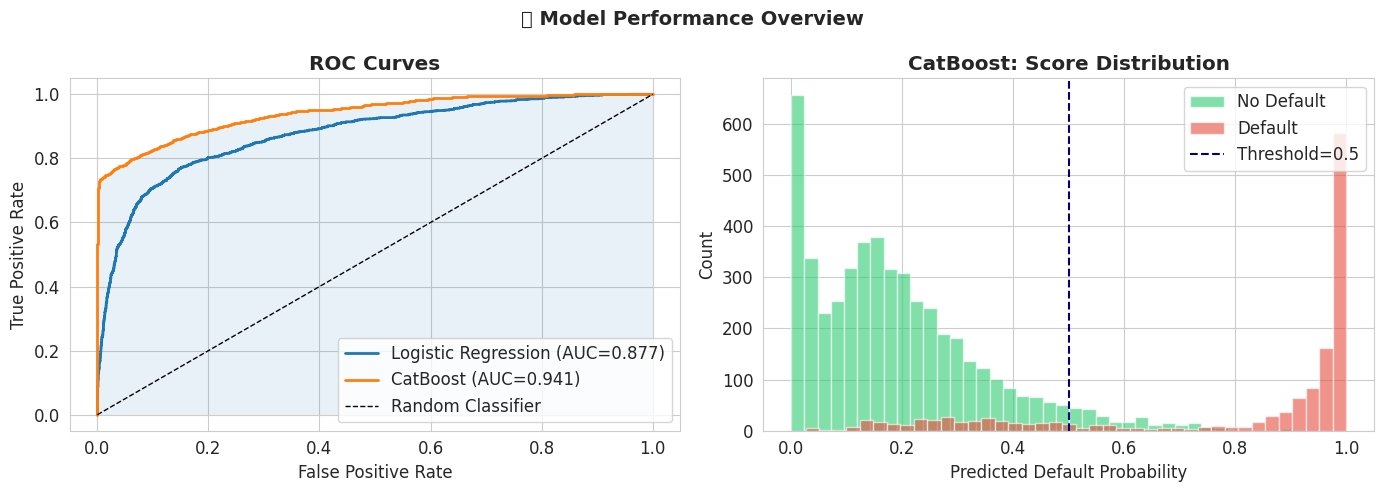

💡 CatBoost (AUC=0.941) outperforms Logistic Regression (AUC=0.877)
   The score distribution overlap shows why threshold tuning is critical.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── ROC Curves
ax = axes[0]
for name, probs, auc in [
    ('Logistic Regression', lr_probs, lr_auc),
    ('CatBoost',            cb_probs, cb_auc)
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
ax.fill_between(*roc_curve(y_test, cb_probs)[:2], alpha=0.1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend(loc='lower right')

# ── Probability Distribution
ax = axes[1]
ax.hist(cb_probs[y_test==0], bins=40, alpha=0.6, color='#2ecc71', label='No Default')
ax.hist(cb_probs[y_test==1], bins=40, alpha=0.6, color='#e74c3c', label='Default')
ax.axvline(0.5, color='navy', linestyle='--', label='Threshold=0.5')
ax.set_xlabel('Predicted Default Probability')
ax.set_ylabel('Count')
ax.set_title('CatBoost: Score Distribution', fontweight='bold')
ax.legend()

plt.suptitle('📈 Model Performance Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'💡 CatBoost (AUC={cb_auc:.3f}) outperforms Logistic Regression (AUC={lr_auc:.3f})')
print('   The score distribution overlap shows why threshold tuning is critical.')

## 💰 Step 8: Business Cost Analysis & Threshold Optimization

In credit risk, the two types of errors have very different business costs:

| Error Type | Meaning | Business Impact |
|---|---|---|
| **False Negative (FN)** | We approved a loan that defaulted | 🔴 **HIGH COST** — we lose the loan amount |
| **False Positive (FP)** | We rejected a good borrower | 🟡 **LOWER COST** — we lose potential interest profit |

**Our cost assumptions:**
- FN cost = $500 per missed default (partial loss estimate)
- FP cost = $50 per wrongly rejected customer (lost profit opportunity)

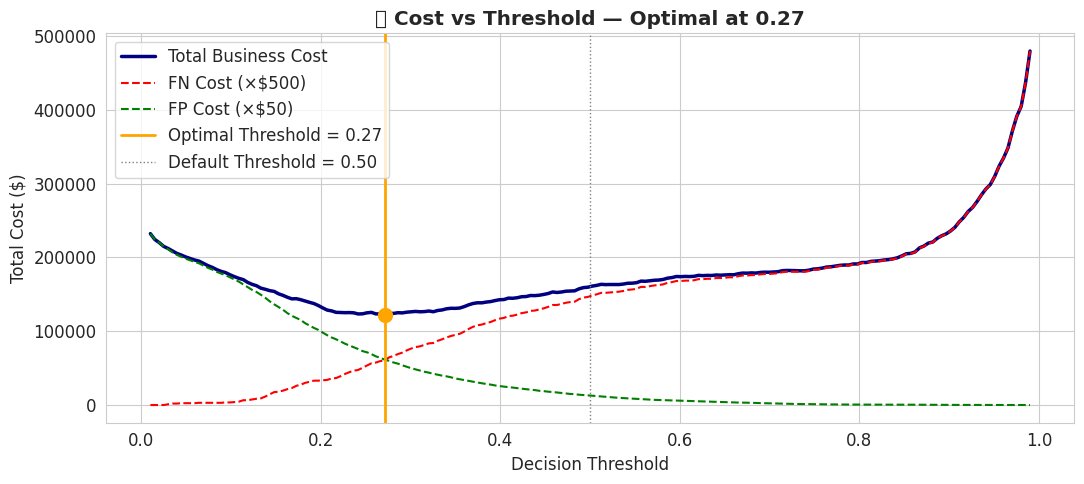

📍 Default threshold (0.50) total cost: $159,600
📍 Optimal threshold (0.27) total cost: $122,000
💵 Cost savings from threshold tuning:  $37,600

💡 By lowering the threshold, we catch more defaults (fewer FNs)
   at the expense of rejecting more good borrowers (more FPs).
   Since FN costs 10× more than FP, we shift the threshold lower.


In [12]:
# ── Define Business Costs
COST_FN = 500   # Missing a default (most expensive)
COST_FP = 50    # Wrongly rejecting a good borrower

# ── Sweep thresholds from 0.01 to 0.99
thresholds = np.linspace(0.01, 0.99, 200)
total_costs, fn_costs, fp_costs = [], [], []

for thresh in thresholds:
    preds = (cb_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    total  = fp * COST_FP + fn * COST_FN
    total_costs.append(total)
    fn_costs.append(fn * COST_FN)
    fp_costs.append(fp * COST_FP)

# ── Find optimal threshold
optimal_idx   = np.argmin(total_costs)
optimal_thresh = thresholds[optimal_idx]
optimal_cost  = total_costs[optimal_idx]

# ── Plot cost curves
plt.figure(figsize=(11, 5))
plt.plot(thresholds, total_costs, 'navy', lw=2.5, label='Total Business Cost')
plt.plot(thresholds, fn_costs,    'red',  lw=1.5, linestyle='--', label=f'FN Cost (×${COST_FN})')
plt.plot(thresholds, fp_costs,    'green',lw=1.5, linestyle='--', label=f'FP Cost (×${COST_FP})')
plt.axvline(optimal_thresh, color='orange', linewidth=2,
            label=f'Optimal Threshold = {optimal_thresh:.2f}')
plt.axvline(0.5, color='grey', linewidth=1, linestyle=':', label='Default Threshold = 0.50')
plt.scatter([optimal_thresh], [optimal_cost], color='orange', zorder=5, s=100)
plt.xlabel('Decision Threshold')
plt.ylabel('Total Cost ($)')
plt.title(f'💰 Cost vs Threshold — Optimal at {optimal_thresh:.2f}', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Compare costs at 0.5 vs optimal
default_idx  = np.argmin(np.abs(thresholds - 0.5))
default_cost = total_costs[default_idx]

savings = default_cost - optimal_cost
print(f'📍 Default threshold (0.50) total cost: ${default_cost:,.0f}')
print(f'📍 Optimal threshold ({optimal_thresh:.2f}) total cost: ${optimal_cost:,.0f}')
print(f'💵 Cost savings from threshold tuning:  ${savings:,.0f}')
print(f'\n💡 By lowering the threshold, we catch more defaults (fewer FNs)')
print(f'   at the expense of rejecting more good borrowers (more FPs).')
print(f'   Since FN costs 10× more than FP, we shift the threshold lower.')

## 🎯 Step 9: Final Model Evaluation at Optimal Threshold

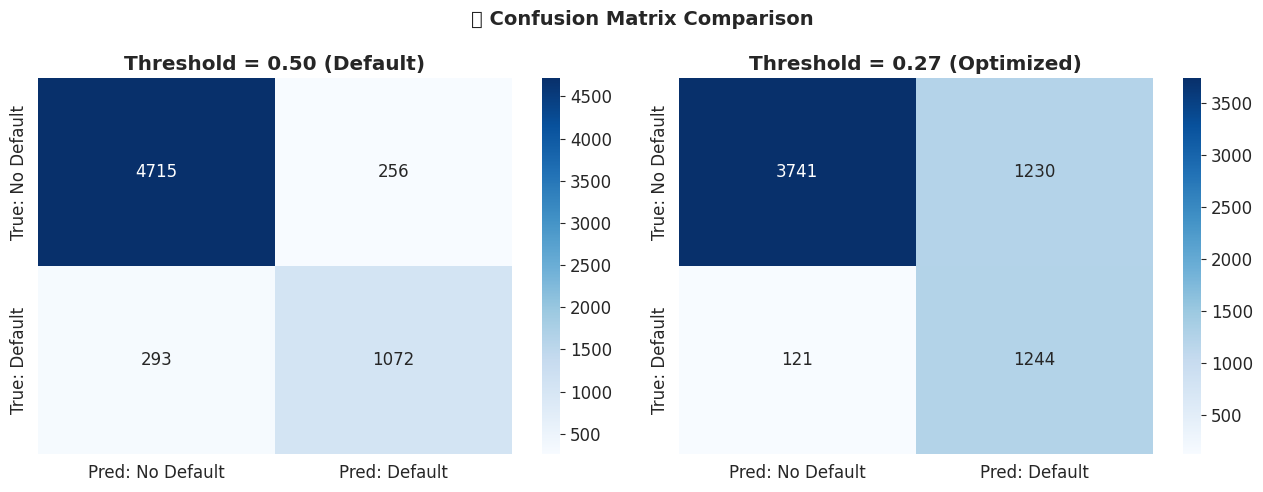


--- Classification Report at DEFAULT threshold (0.50) ---
              precision    recall  f1-score   support

  No Default       0.94      0.95      0.94      4971
     Default       0.81      0.79      0.80      1365

    accuracy                           0.91      6336
   macro avg       0.87      0.87      0.87      6336
weighted avg       0.91      0.91      0.91      6336

--- Classification Report at OPTIMAL threshold (0.27) ---
              precision    recall  f1-score   support

  No Default       0.97      0.75      0.85      4971
     Default       0.50      0.91      0.65      1365

    accuracy                           0.79      6336
   macro avg       0.74      0.83      0.75      6336
weighted avg       0.87      0.79      0.80      6336

💡 At the optimal threshold:
   • Recall for Default class improves — we catch more actual defaults
   • Precision for Default class may drop — more false alarms on good borrowers
   • But the TOTAL BUSINESS COST is lower — that i

In [13]:
# Predictions at both thresholds
preds_default = (cb_probs >= 0.50).astype(int)
preds_optimal = (cb_probs >= optimal_thresh).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, title in [
    (axes[0], preds_default, f'Threshold = 0.50 (Default)'),
    (axes[1], preds_optimal, f'Threshold = {optimal_thresh:.2f} (Optimized)'),
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: No Default','Pred: Default'],
                yticklabels=['True: No Default','True: Default'])
    ax.set_title(title, fontweight='bold')

plt.suptitle('🎯 Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n--- Classification Report at DEFAULT threshold (0.50) ---')
print(classification_report(y_test, preds_default, target_names=['No Default','Default']))

print(f'--- Classification Report at OPTIMAL threshold ({optimal_thresh:.2f}) ---')
print(classification_report(y_test, preds_optimal, target_names=['No Default','Default']))

print('💡 At the optimal threshold:')
print('   • Recall for Default class improves — we catch more actual defaults')
print('   • Precision for Default class may drop — more false alarms on good borrowers')
print('   • But the TOTAL BUSINESS COST is lower — that is what matters')

## 🔑 Step 10: Feature Importance Analysis

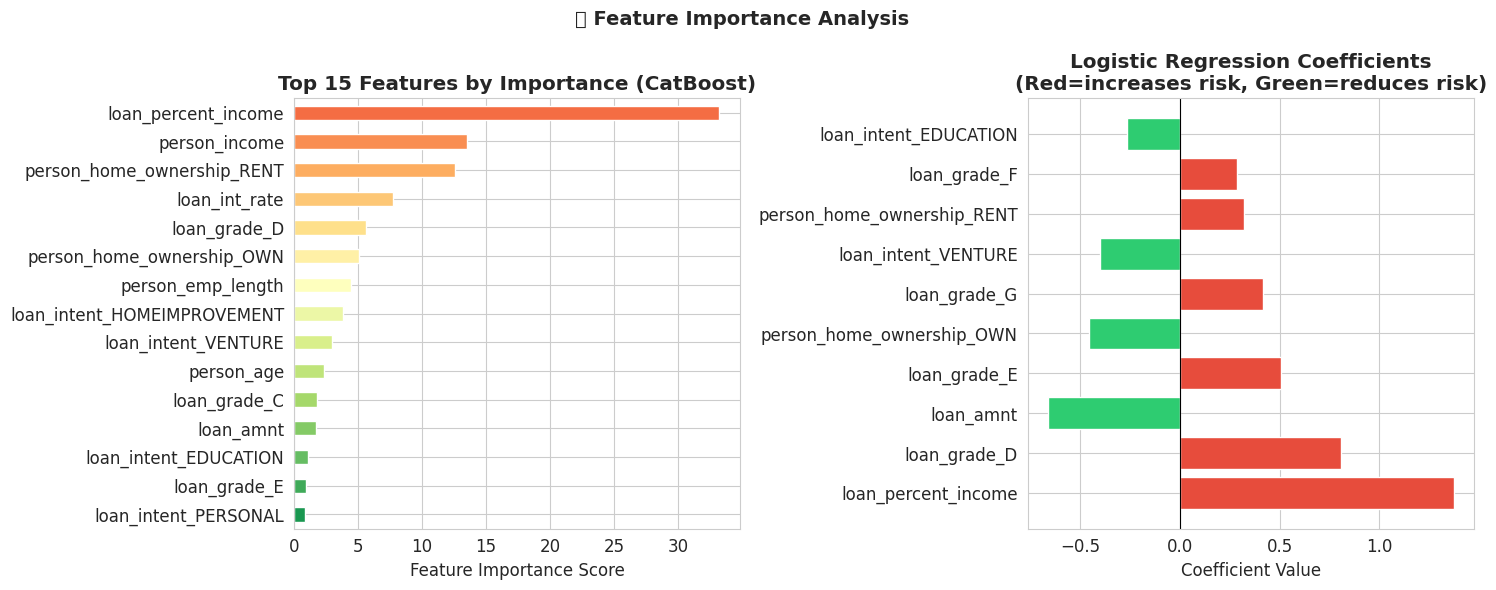

💡 Key Risk Drivers:
   Top 3 by CatBoost: ['loan_percent_income', 'person_income', 'person_home_ownership_RENT']
   • loan_percent_income: High loan-to-income ratio is a strong default predictor
   • loan_int_rate: Higher interest signals riskier borrowers
   • loan_grade: Grade encapsulates multiple risk factors
   • cb_person_default_on_file: Past default behavior is a strong recurrence signal


In [14]:
# CatBoost Feature Importance
importance = pd.Series(
    cb_model.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=True)

# Show top 15 features
top15 = importance.tail(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Horizontal bar chart
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top15)))
top15.plot(kind='barh', ax=axes[0], color=colors[::-1], edgecolor='white')
axes[0].set_title('Top 15 Features by Importance (CatBoost)', fontweight='bold')
axes[0].set_xlabel('Feature Importance Score')

# ── Logistic Regression coefficients
lr_coef = pd.Series(lr_model.coef_[0], index=X_train.columns)
top_lr  = lr_coef.abs().sort_values(ascending=False).head(10)
colors2 = ['#e74c3c' if lr_coef[f] > 0 else '#2ecc71' for f in top_lr.index]

axes[1].barh(top_lr.index, lr_coef[top_lr.index], color=colors2, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Logistic Regression Coefficients\n(Red=increases risk, Green=reduces risk)',
                  fontweight='bold')
axes[1].set_xlabel('Coefficient Value')

plt.suptitle('🔑 Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Key Risk Drivers:')
print(f'   Top 3 by CatBoost: {importance.tail(3).index.tolist()[::-1]}')
print('   • loan_percent_income: High loan-to-income ratio is a strong default predictor')
print('   • loan_int_rate: Higher interest signals riskier borrowers')
print('   • loan_grade: Grade encapsulates multiple risk factors')
print('   • cb_person_default_on_file: Past default behavior is a strong recurrence signal')

## 🗂️ Step 11: Risk Scoring — Assign Risk Tiers

--- Risk Tier Summary ---
                count  actual_default_rate  avg_pred_prob
risk_tier                                                
Low Risk         3056                  2.2            9.4
Medium Risk      1641                 10.2           28.1
High Risk         492                 20.7           48.2
Very High Risk   1147                 89.7           92.8


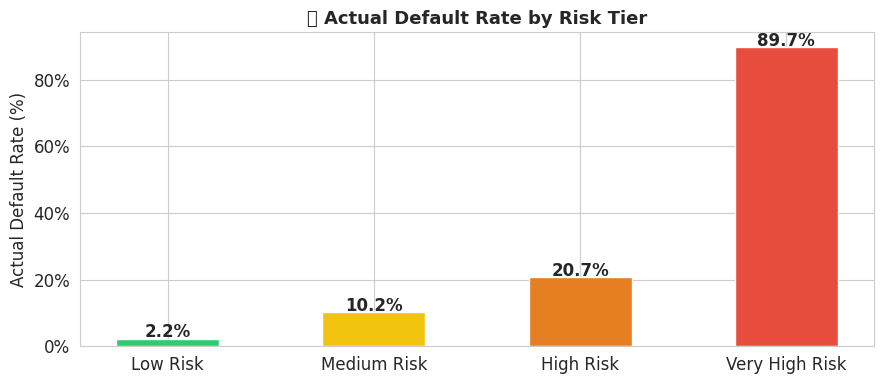


💡 Risk tiers validate model calibration.
   Very High Risk should have the highest actual default rate — if it does, the model is well-calibrated.


In [15]:
# Assign risk buckets based on predicted probability
results = X_test.copy()
results['true_label'] = y_test.values
results['default_prob'] = cb_probs

def assign_risk(prob):
    if prob < 0.20:   return 'Low Risk'
    elif prob < 0.40: return 'Medium Risk'
    elif prob < 0.60: return 'High Risk'
    else:             return 'Very High Risk'

results['risk_tier'] = results['default_prob'].apply(assign_risk)

# Actual default rate within each tier
tier_stats = results.groupby('risk_tier').agg(
    count=('true_label', 'count'),
    actual_default_rate=('true_label', 'mean'),
    avg_pred_prob=('default_prob', 'mean')
).reindex(['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk'])

tier_stats['actual_default_rate'] = (tier_stats['actual_default_rate'] * 100).round(1)
tier_stats['avg_pred_prob']        = (tier_stats['avg_pred_prob'] * 100).round(1)

print('--- Risk Tier Summary ---')
print(tier_stats.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(9, 4))
colors3 = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = ax.bar(tier_stats.index, tier_stats['actual_default_rate'],
              color=colors3, edgecolor='white', width=0.5)

for bar, val in zip(bars, tier_stats['actual_default_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')

ax.set_title('🗂️ Actual Default Rate by Risk Tier', fontweight='bold', fontsize=13)
ax.set_ylabel('Actual Default Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

print('\n💡 Risk tiers validate model calibration.')
print('   Very High Risk should have the highest actual default rate — if it does, the model is well-calibrated.')

## 📊 Step 12: Final Summary Dashboard

In [16]:
from sklearn.metrics import recall_score, precision_score, f1_score

print('=' * 60)
print('       📋 FINAL MODEL SUMMARY REPORT')
print('=' * 60)

for name, probs, model_label in [
    ('Logistic Regression', lr_probs, 'LR'),
    ('CatBoost',            cb_probs, 'CB')
]:
    # at 0.5
    preds_05 = (probs >= 0.50).astype(int)
    # at optimal
    t_ = optimal_thresh if model_label == 'CB' else 0.50
    preds_opt = (probs >= t_).astype(int)

    print(f'\n🔷 {name}')
    print(f'   ROC-AUC       : {roc_auc_score(y_test, probs):.4f}')
    print(f'   Threshold     : 0.50  →  Recall(Default)={recall_score(y_test, preds_05):.3f}  '
          f'Precision(Default)={precision_score(y_test, preds_05):.3f}')
    if model_label == 'CB':
        print(f'   Threshold     : {t_:.2f}  →  Recall(Default)={recall_score(y_test, preds_opt):.3f}  '
              f'Precision(Default)={precision_score(y_test, preds_opt):.3f}')

print(f'\n💰 COST OPTIMIZATION SUMMARY')
print(f'   FN Cost per missed default : ${COST_FN}')
print(f'   FP Cost per false alarm    : ${COST_FP}')
print(f'   Default threshold (0.50) cost : ${default_cost:>10,.0f}')
print(f'   Optimal threshold ({optimal_thresh:.2f}) cost  : ${optimal_cost:>10,.0f}')
print(f'   💵 Business savings          : ${savings:>10,.0f}')

print(f'\n🔑 TOP RISK FACTORS')
top_features = importance.tail(5).index.tolist()[::-1]
for i, f in enumerate(top_features, 1):
    print(f'   {i}. {f}')

print('\n' + '=' * 60)
print('✅ Analysis complete. Deploy CatBoost with optimized threshold.')
print('=' * 60)

       📋 FINAL MODEL SUMMARY REPORT

🔷 Logistic Regression
   ROC-AUC       : 0.8769
   Threshold     : 0.50  →  Recall(Default)=0.790  Precision(Default)=0.549

🔷 CatBoost
   ROC-AUC       : 0.9412
   Threshold     : 0.50  →  Recall(Default)=0.785  Precision(Default)=0.807
   Threshold     : 0.27  →  Recall(Default)=0.911  Precision(Default)=0.503

💰 COST OPTIMIZATION SUMMARY
   FN Cost per missed default : $500
   FP Cost per false alarm    : $50
   Default threshold (0.50) cost : $   159,600
   Optimal threshold (0.27) cost  : $   122,000
   💵 Business savings          : $    37,600

🔑 TOP RISK FACTORS
   1. loan_percent_income
   2. person_income
   3. person_home_ownership_RENT
   4. loan_int_rate
   5. loan_grade_D

✅ Analysis complete. Deploy CatBoost with optimized threshold.
